# Bankruptcy Prediction - Exploratory Data Analysis

*Target:* `Bankrupt` ( `No` = Healthy, `Yes` = Bankrupt)

## 1. Import and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"data\bankruptcy.csv")
print(df.shape)


df.head()

(6819, 95)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,...,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability
0,No,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,...,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956
1,No,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,...,0,0.804106,0.007002,0.623701,0.602091,0.840783,0.281189,0.027200,0.566564,0.025107
2,No,0.465315,0.515645,0.511591,0.593782,0.593782,0.998961,0.797354,0.809277,0.303480,...,0,0.785955,0.008955,0.623801,0.593777,0.839341,0.278153,0.026630,0.564252,0.038119
3,No,0.506118,0.556912,0.547727,0.615820,0.615820,0.999169,0.797528,0.809401,0.303348,...,0,0.810229,0.000662,0.623844,0.615818,0.840996,0.277714,0.026863,0.565477,0.042154
4,No,0.539170,0.593273,0.586273,0.606949,0.606949,0.999077,0.797485,0.809394,0.303465,...,0,0.827668,0.001374,0.623774,0.606948,0.842516,0.279316,0.026818,0.565285,0.031117


## 2. Data Overview and Missing Values / Duplicate Search

In [3]:
print("Dtypes:")
print(df.dtypes.value_counts())

Dtypes:
float64    93
object      1
int64       1
Name: count, dtype: int64


In [4]:
df.describe(include='all').head(20).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Bankrupt,6819,2,No,6599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROA_C_Before_Interest_Depreciation,6819.0,NaN,NaN,NaN,0.50518,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA_A_Before_Interest_After_Tax,6819.0,NaN,NaN,NaN,0.558625,0.06562,0.0,0.535543,0.559802,0.589157,1.0
ROA_B_Before_Interest_Depreciation_After_Tax,6819.0,NaN,NaN,NaN,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating_Gross_Margin,6819.0,NaN,NaN,NaN,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...,...,...,...
Net_Income_to_Stockholders_Equity,6819.0,NaN,NaN,NaN,0.840402,0.014523,0.0,0.840115,0.841179,0.842357,1.0
Liability_to_Equity,6819.0,NaN,NaN,NaN,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
DFL,6819.0,NaN,NaN,NaN,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest_Coverage_Ratio,6819.0,NaN,NaN,NaN,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0


In [5]:
print("Columns With Missing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")


print(f'\nColumns With Duplicates: ')
print(df.duplicated().astype(int))
print(f"Total Number of Duplicated Rows {df.duplicated().sum()}")

Columns With Missing Values:
Bankrupt                                        0
ROA_C_Before_Interest_Depreciation              0
ROA_A_Before_Interest_After_Tax                 0
ROA_B_Before_Interest_Depreciation_After_Tax    0
Operating_Gross_Margin                          0
                                               ..
Net_Income_to_Stockholders_Equity               0
Liability_to_Equity                             0
DFL                                             0
Interest_Coverage_Ratio                         0
Equity_to_Liability                             0
Length: 95, dtype: int64
Total Missing Values: 0

Columns With Duplicates: 
0       0
1       0
2       0
3       0
4       0
       ..
6814    0
6815    0
6816    0
6817    0
6818    0
Length: 6819, dtype: int64
Total Number of Duplicated Rows 0


## 3. Target Variable Analysis

In [6]:
df['Bankrupt'] = df['Bankrupt'].map({'No' : 0, 'Yes': 1})

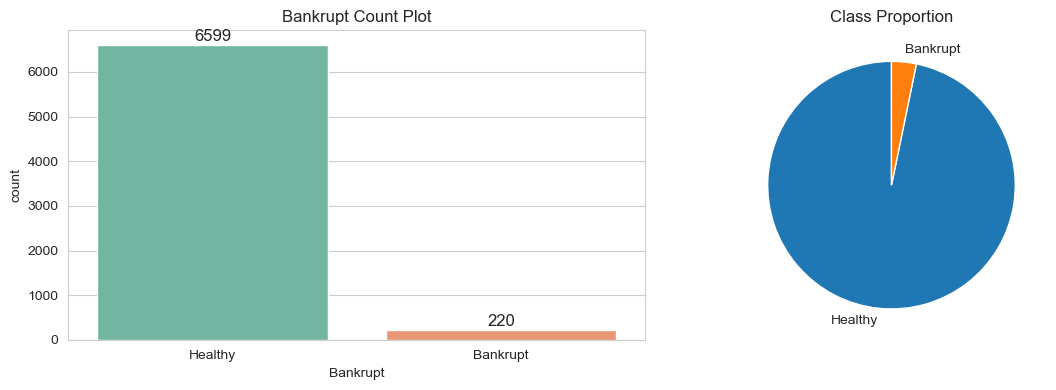

In [7]:
fig , axes = plt.subplots(1,2 , figsize =(12, 4))

target_count = df['Bankrupt'].value_counts().sort_index()

sns.countplot(x=df['Bankrupt'], palette='Set2', ax=axes[0], legend= True)
axes[0].set_title("Bankrupt Count Plot")
axes[0].set_xticklabels(['Healthy','Bankrupt'])
for i , v in enumerate(target_count):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=12)
    
axes[1].pie(target_count,labels =['Healthy','Bankrupt'], startangle = 90)
axes[1].set_title("Class Proportion")

plt.tight_layout();     plt.show()

In [8]:
print("Class Balance (%): ")
print(f"Healthy : {(df["Bankrupt"] == 0).sum() / len(df['Bankrupt']) * 100 :.2f}%")
print(f"Bankrupt : {((df["Bankrupt"] == 1).sum() / len(df['Bankrupt'])* 100).round(2)}%")


Class Balance (%): 
Healthy : 96.77%
Bankrupt : 3.23%


## 4. Univariate Variable Analysis - Numerical Columns

In [9]:
num_col = df.drop(columns = "Bankrupt").columns.to_list()
print(num_col)

['ROA_C_Before_Interest_Depreciation', 'ROA_A_Before_Interest_After_Tax', 'ROA_B_Before_Interest_Depreciation_After_Tax', 'Operating_Gross_Margin', 'Realized_Sales_Gross_Margin', 'Operating_Profit_Rate', 'PreTax_Net_Interest_Rate', 'AfterTax_Net_Interest_Rate', 'NonIndustry_Income_Expenditure_Revenue', 'Continuous_Interest_Rate_After_Tax', 'Operating_Expense_Rate', 'R&D_Expense_Rate', 'Cash_Flow_Rate', 'InterestBearing_Debt_Interest_Rate', 'Tax_Rate_A', 'Net_Value_Per_Share_B', 'Net_Value_Per_Share_A', 'Net_Value_Per_Share_C', 'Persistent_EPS_Last_4_Seasons', 'Cash_Flow_Per_Share', 'Revenue_Per_Share', 'Operating_Profit_Per_Share', 'Net_Profit_Before_Tax_Per_Share', 'Realized_Sales_Gross_Profit_Growth_Rate', 'Operating_Profit_Growth_Rate', 'AfterTax_Net_Profit_Growth_Rate', 'Regular_Net_Profit_Growth_Rate', 'Continuous_Net_Profit_Growth_Rate', 'Total_Asset_Growth_Rate', 'Net_Value_Growth_Rate', 'Total_Asset_Return_Growth_Rate', 'Cash_Reinvestment_Percent', 'Current_Ratio', 'Quick_Ratio

In [10]:
df.describe(include= 'int64')

,Bankrupt,Liability_Assets_Flag
count,6819.000000,6819.000000
mean,0.032263,0.001173
std,0.176710,0.034234
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


In [11]:
stew_col= df.select_dtypes(include='number').drop(columns= 'Bankrupt')
skewedness = stew_col.skew().sort_values(ascending = False)
skew_col = skewedness[abs(skewedness) > 1]
not_skew = skewedness[abs(skewedness) < 1]

print("Features that are skewed:\n")
print(skew_col)
print("\nFeatures that are not skewed:")
print(not_skew)

Features that are skewed:

Fixed_Assets_to_Assets                 82.577237
Current_Ratio                          82.577237
Total_Income_to_Total_Expense          82.332424
Net_Value_Growth_Rate                  80.291844
Contingent_Liabilities_to_Net_Worth    79.670620
                                         ...    
PreTax_Net_Interest_Rate              -52.482867
AfterTax_Net_Interest_Rate            -52.995744
Continuous_Interest_Rate_After_Tax    -53.200121
Operating_Profit_Rate                 -70.237164
Operating_Profit_Growth_Rate          -71.688950
Length: 81, dtype: float64

Features that are not skewed:
Debt_Ratio_Percent                              0.980796
Cash_Turnover_Rate                              0.954117
Quick_Assets_to_Total_Assets                    0.337315
Current_Assets_to_Total_Assets                  0.075890
Working_Capital_to_Total_Assets                -0.192311
Cash_Flow_to_Total_Assets                      -0.228158
ROA_C_Before_Interest_Depreciation

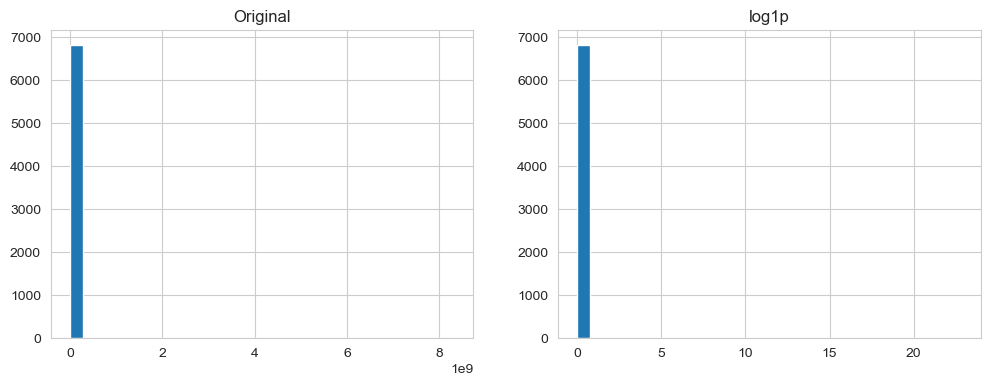

In [12]:
feature = "Fixed_Assets_to_Assets"

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(df[feature], bins=30)
ax[0].set_title("Original")

ax[1].hist(np.log1p(df[feature]), bins=30)
ax[1].set_title("log1p")

plt.show()

As of the skewness , the `np.log1p()` did not really work much so i have to change to 
Yeo-Johnson Transformation ( PowerTransformer)

In [13]:
from sklearn.preprocessing import PowerTransformer

x_trans = df.copy()
pt = PowerTransformer()

x_trans = pt.fit_transform(x_trans[num_col])

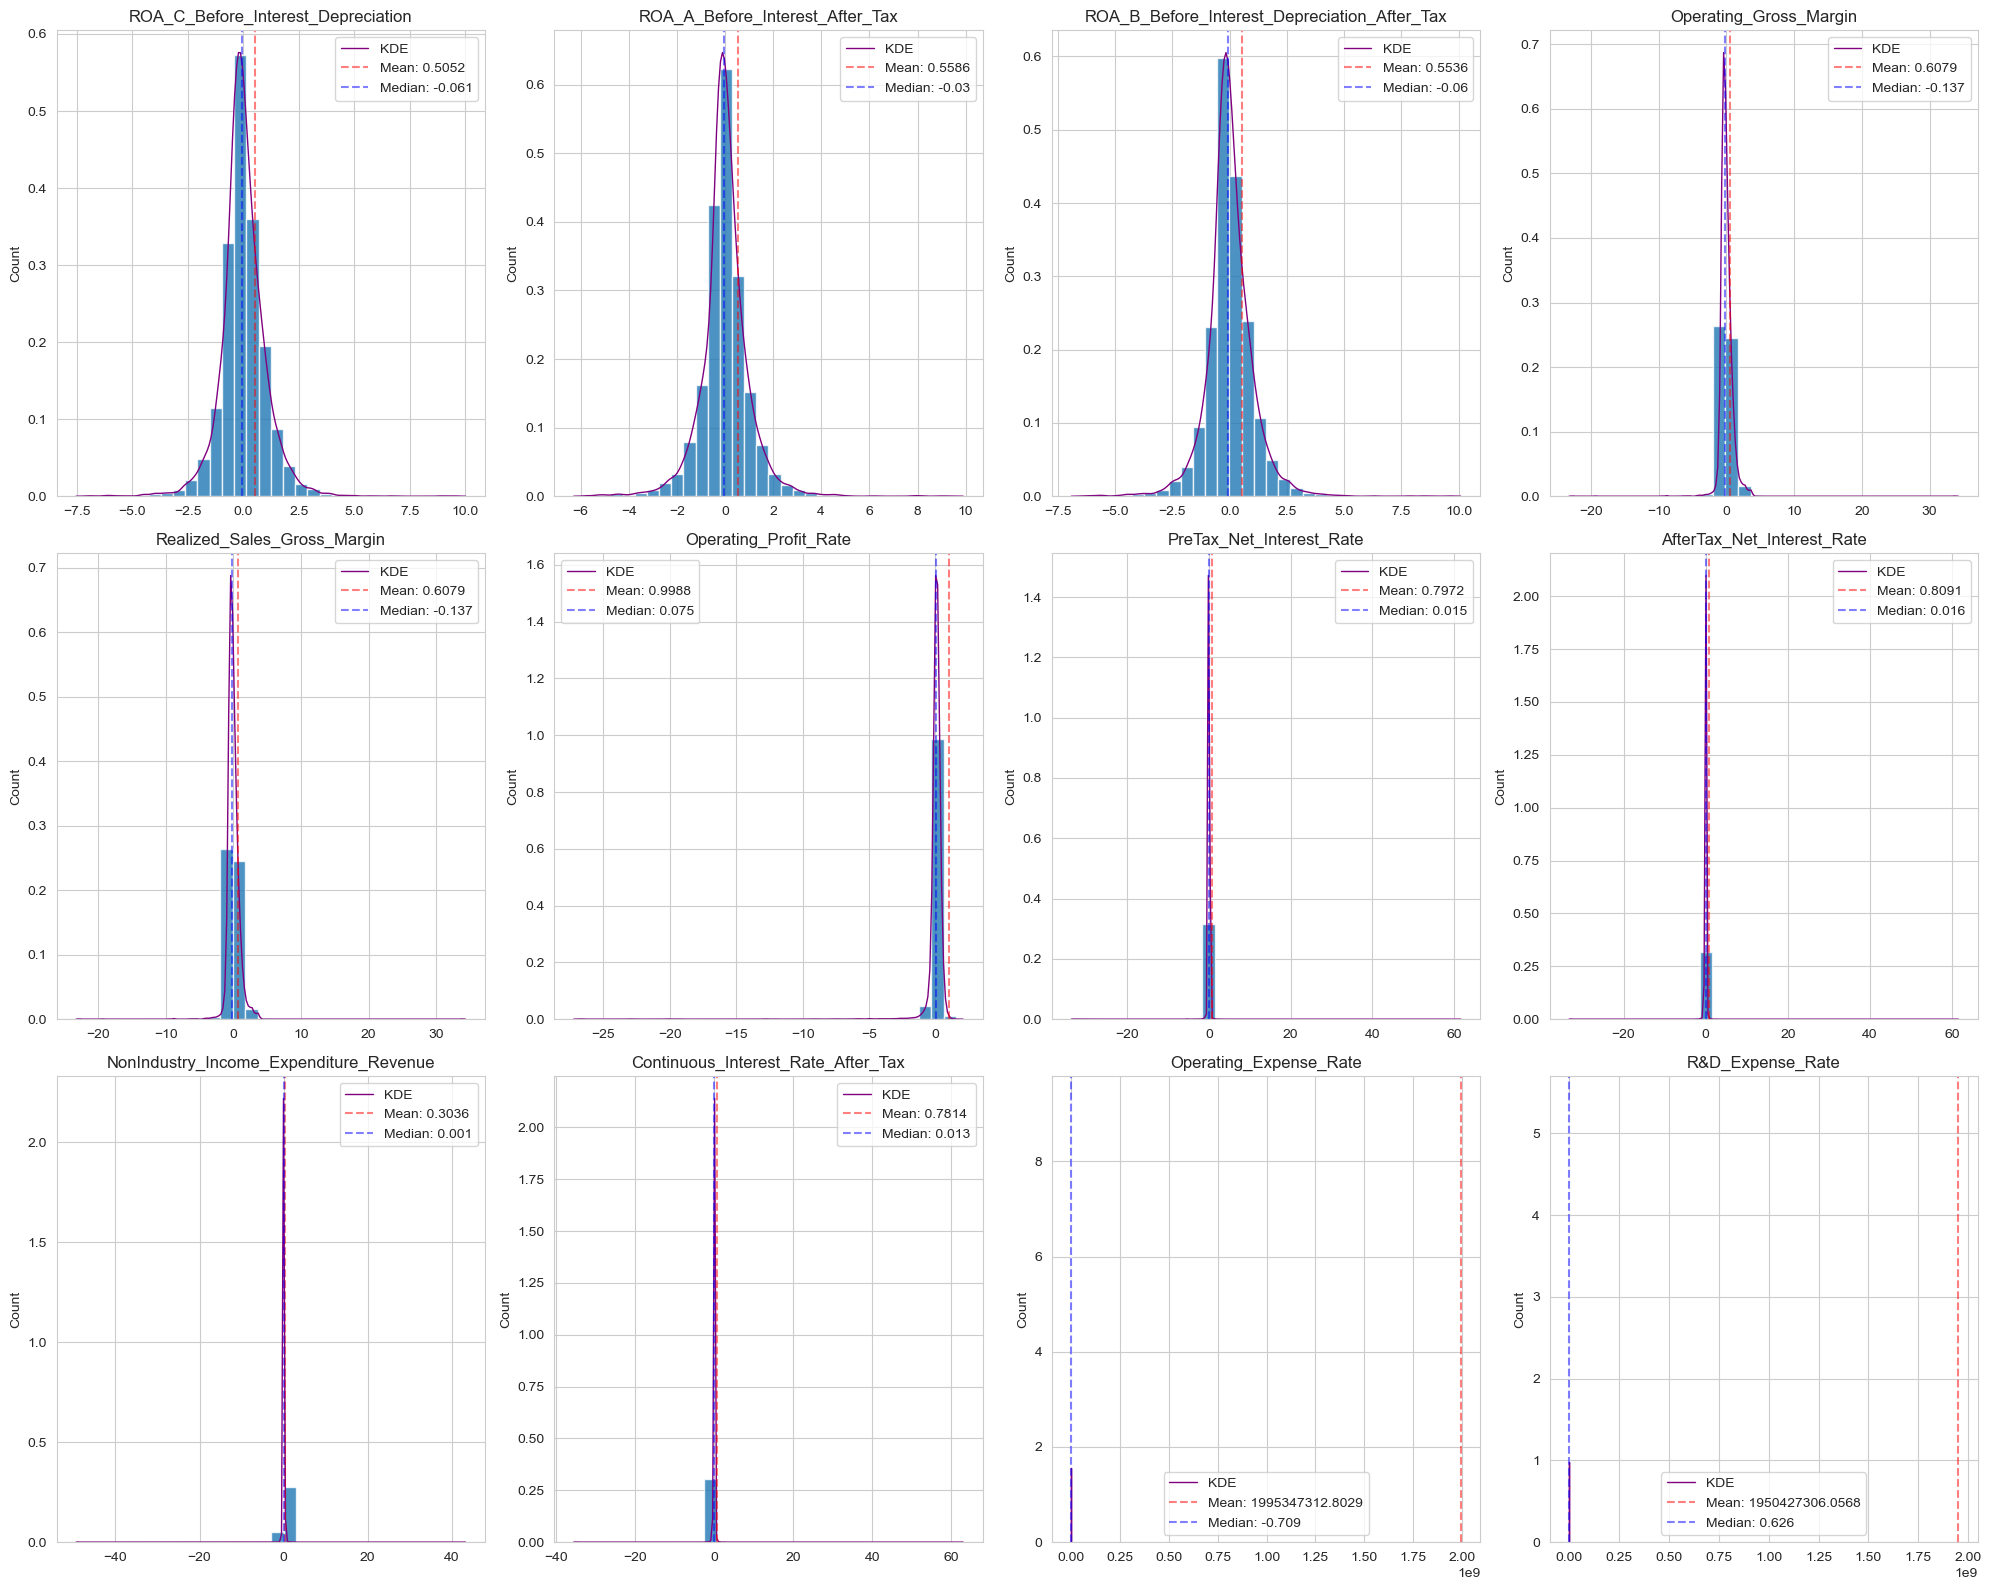

In [ ]:
fig, axes = plt.subplots(3, 4 , figsize=(20,16))

ncoln = num_col[:12]        # Use 10 Feature for the univariate analysis
axes = axes.flatten()

for i ,v in enumerate(ncoln):
    x_t = x_trans[:, num_col.index(v)]
    
    axes[i].hist(x_t, bins= 30, edgecolor= 'white', alpha =0.8, density=True)
    sns.kdeplot(x=x_t, ax=axes[i], color='purple', linewidth=1, label='KDE')
    
    axes[i].axvline(df[v].mean(), linestyle= '--', color='red', label = f"Mean: {df[v].mean().round(3)}", alpha= 0.5)
    axes[i].axvline(np.median(x_t), linestyle= '--', color='blue', label = f"Median: {np.median(x_t).round(3)}",  alpha= 0.5)

    axes[i].set_title(v);  axes[i].set_ylabel("Count")
    axes[i].legend()
    

plt.tight_layout()
plt.show()

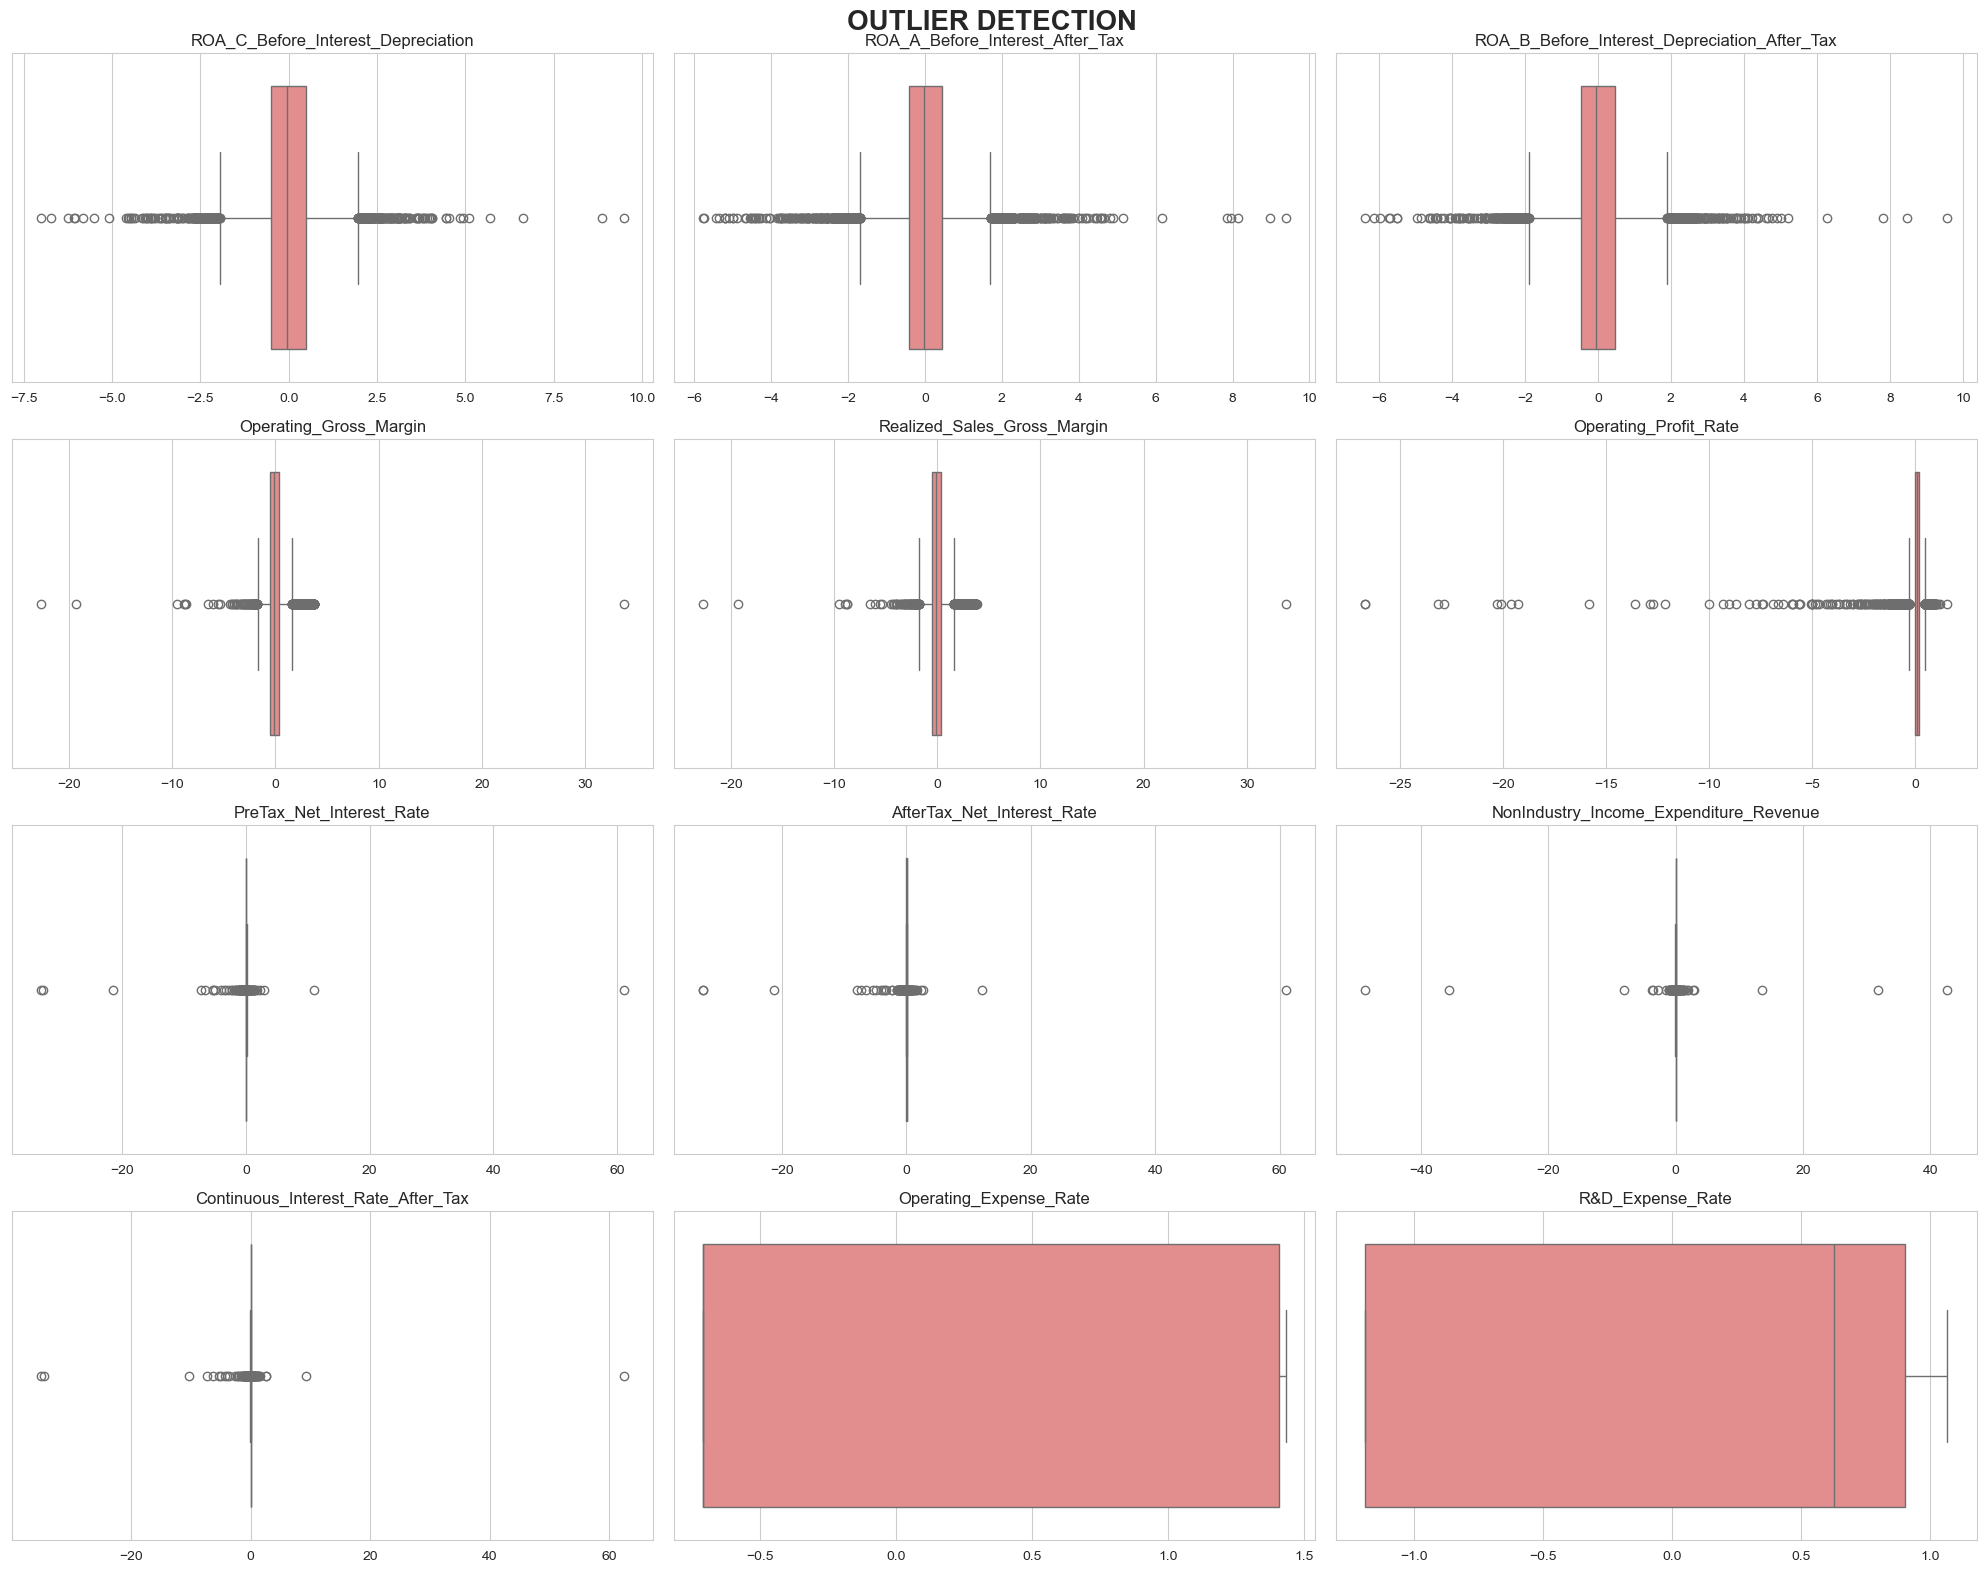

In [32]:
# Check for Numerical Outliers
fig, axes = plt.subplots(4, 3,figsize= (20, 16))

axes= axes.flatten()
for i , v in enumerate(ncoln):
    sns.boxplot(x= x_trans[:, num_col.index(v)], color='lightcoral', ax =axes[i])
    axes[i].set_title(v)
    
plt.suptitle("OUTLIER DETECTION", fontweight= 'bold', fontsize = 20)
plt.tight_layout();     plt.show()

## 5. Bivariate Analysis - Target Vs Feature
Get the top features by correlation and pair them with the target `Bankrupt`

In [54]:
corr_data = df.corr()['Bankrupt'].abs().sort_values(ascending=False).drop('Bankrupt')
 
print("Top 5 Features with the Highest Corr_ value are: ")
print(corr_data[:5])

Top 5 Features with the Highest Corr_ value are: 
Net_Income_to_Total_Assets                      0.315457
ROA_A_Before_Interest_After_Tax                 0.282941
ROA_B_Before_Interest_Depreciation_After_Tax    0.273051
ROA_C_Before_Interest_Depreciation              0.260807
Debt_Ratio_Percent                              0.250161
Name: Bankrupt, dtype: float64
